In [1]:
import pandas as pd
import numpy as np


In [60]:
df = pd.read_csv("marketing_campaign.csv", sep=";")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [61]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [62]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [63]:
df.shape

(2240, 29)

In [64]:
df.drop_duplicates(inplace=True)
df.shape

(2240, 29)

In [65]:
income = df['Income']
income.head()

0    58138.0
1    46344.0
2    71613.0
3    26646.0
4    58293.0
Name: Income, dtype: float64

C:\Users\hp\AppData\Local\Temp\ipykernel_18864\3165565221.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(income, color='red')


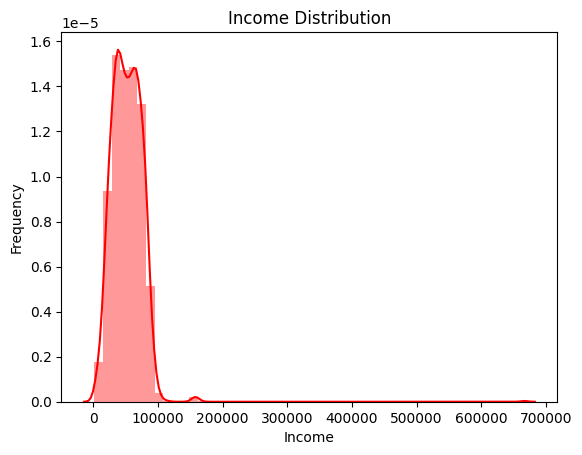

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.distplot(income, color='red')
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

In [67]:
print(income.median())
print(income.mean()) # mean is shifted right side than median signifying potential presence of outliers!

51381.5
52247.25135379061


In [68]:
print(income.skew()) # positively skewed data.
print(income.kurtosis()) #very high kurtosis. Outliers must be there!

6.763487372811116
159.6366995778005


In [ ]:
df['Income'] = df['Income'].fillna(df['Income'].median())# because income is right skewed. So is the mean!
df.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [70]:
income = df['Income']

C:\Users\hp\AppData\Local\Temp\ipykernel_18864\1729968683.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(income, color='red')


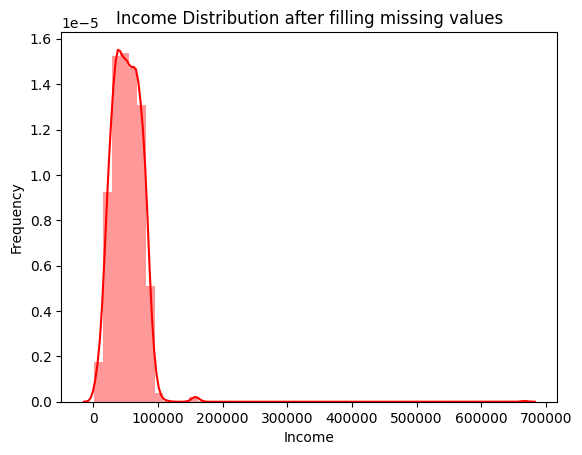

In [71]:
sns.distplot(income, color='red')
plt.title('Income Distribution after filling missing values')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show()

In [72]:
print(income.skew())
print(income.kurtosis())

6.800947406327349
161.40014418235637


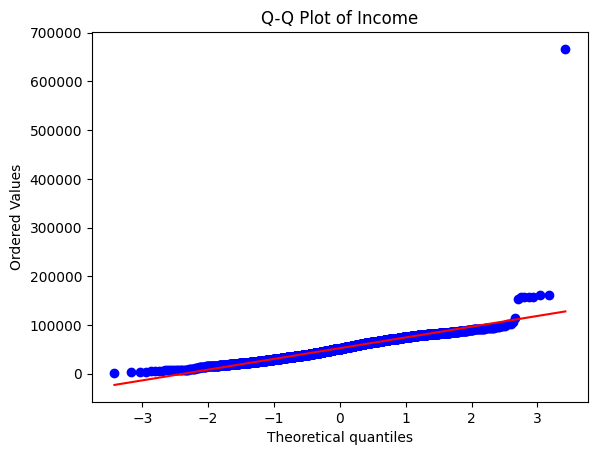

In [73]:
import scipy.stats as stats

stats.probplot(income, dist='norm', plot=plt)
plt.title('Q-Q Plot of Income')
plt.show() # hence near normal distribution.

In [74]:
q1 = np.percentile(income, 25)
q3 = np.percentile(income, 75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(lower_bound)
print(upper_bound)
outliers = income[(income < lower_bound) | (income > upper_bound)]
print(outliers.shape) #outliers are present.

-13587.75
117416.25
(8,)


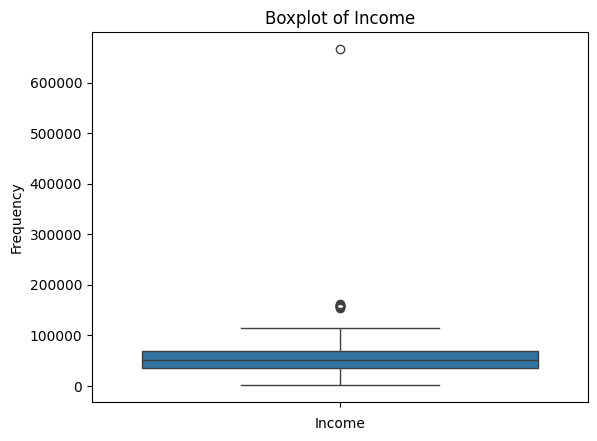

In [75]:
sns.boxplot(income)
plt.title('Boxplot of Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.show() # hence this could be the natural distribution of the data

In [76]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [77]:
birth = df['Year_Birth']
birth.head()

0    1957
1    1954
2    1965
3    1984
4    1981
Name: Year_Birth, dtype: int64

In [78]:
print(birth.dtype) # not datetype!
print(birth.unique())
print(birth.skew())
print(birth.kurtosis())

int64
[1957 1954 1965 1984 1981 1967 1971 1985 1974 1950 1983 1976 1959 1952
 1987 1946 1980 1949 1982 1979 1951 1969 1986 1989 1963 1970 1973 1943
 1975 1996 1968 1964 1977 1978 1955 1966 1988 1948 1958 1972 1960 1945
 1991 1962 1953 1961 1956 1992 1900 1893 1990 1947 1899 1993 1994 1941
 1944 1995 1940]
-0.34994385918269544
0.717464442459137


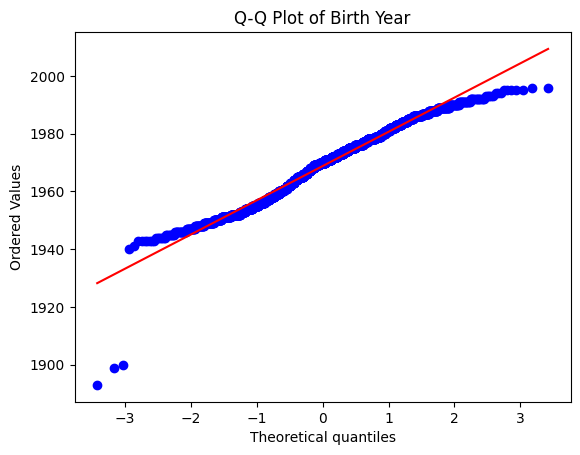

In [79]:
stats.probplot(birth, dist='norm', plot=plt)
plt.title('Q-Q Plot of Birth Year')
plt.show() # near normal distribution but skewed.

C:\Users\hp\AppData\Local\Temp\ipykernel_18864\3763748191.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(birth, color='red')


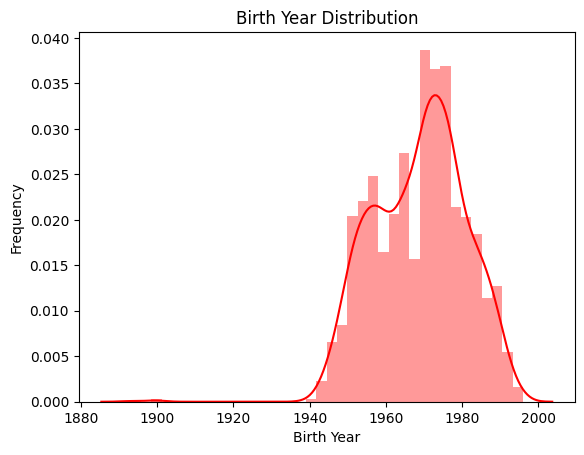

In [80]:
sns.distplot(birth, color='red')
plt.title('Birth Year Distribution')
plt.xlabel('Birth Year')
plt.ylabel('Frequency')
plt.show()

In [81]:
from datetime import datetime

current_year = datetime.now().year

df["Age"] = current_year - df["Year_Birth"]

In [82]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age'],
      dtype='object')

In [83]:
df.drop('Year_Birth', axis=1, inplace=True)
df.columns

Index(['ID', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age'],
      dtype='object')

In [84]:
martial = df['Marital_Status']
martial.value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [85]:
df["Marital_Status"] = df["Marital_Status"].replace({ # decomposition to single value.
    "Alone": "Single",
    "YOLO": "Single",
    "Absurd": "Single"
})
martial = df['Marital_Status']
martial.value_counts()

Marital_Status
Married     864
Together    580
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64

In [86]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
martial_encoded = ohe.fit_transform(df[['Marital_Status']])
martial_encoded_df = pd.DataFrame(martial_encoded, columns=ohe.get_feature_names_out(['Marital_Status']))
df = pd.concat([df, martial_encoded_df], axis=1)
df

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,5524,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,0,3,11,1,69,0.0,0.0,1.0,0.0,0.0
1,2174,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,0,3,11,0,72,0.0,0.0,1.0,0.0,0.0
2,4141,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,0,3,11,0,61,0.0,0.0,0.0,1.0,0.0
3,6182,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,0,3,11,0,42,0.0,0.0,0.0,1.0,0.0
4,5324,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,0,3,11,0,45,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,Graduation,Married,61223.0,0,1,2013-06-13,46,709,43,...,0,3,11,0,59,0.0,1.0,0.0,0.0,0.0
2236,4001,PhD,Together,64014.0,2,1,2014-06-10,56,406,0,...,0,3,11,0,80,0.0,0.0,0.0,1.0,0.0
2237,7270,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,48,...,0,3,11,0,45,1.0,0.0,0.0,0.0,0.0
2238,8235,Master,Together,69245.0,0,1,2014-01-24,8,428,30,...,0,3,11,0,70,0.0,0.0,0.0,1.0,0.0


In [87]:
df.drop('Marital_Status', axis=1, inplace=True)
df

,ID,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,5524,Graduation,58138.0,0,0,2012-09-04,58,635,88,546,...,0,3,11,1,69,0.0,0.0,1.0,0.0,0.0
1,2174,Graduation,46344.0,1,1,2014-03-08,38,11,1,6,...,0,3,11,0,72,0.0,0.0,1.0,0.0,0.0
2,4141,Graduation,71613.0,0,0,2013-08-21,26,426,49,127,...,0,3,11,0,61,0.0,0.0,0.0,1.0,0.0
3,6182,Graduation,26646.0,1,0,2014-02-10,26,11,4,20,...,0,3,11,0,42,0.0,0.0,0.0,1.0,0.0
4,5324,PhD,58293.0,1,0,2014-01-19,94,173,43,118,...,0,3,11,0,45,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,Graduation,61223.0,0,1,2013-06-13,46,709,43,182,...,0,3,11,0,59,0.0,1.0,0.0,0.0,0.0
2236,4001,PhD,64014.0,2,1,2014-06-10,56,406,0,30,...,0,3,11,0,80,0.0,0.0,0.0,1.0,0.0
2237,7270,Graduation,56981.0,0,0,2014-01-25,91,908,48,217,...,0,3,11,0,45,1.0,0.0,0.0,0.0,0.0
2238,8235,Master,69245.0,0,1,2014-01-24,8,428,30,214,...,0,3,11,0,70,0.0,0.0,0.0,1.0,0.0


In [88]:
df['Dt_Customer'].dtype

dtype('O')

In [89]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
df['Dt_Customer'].dtype #changing dtype to date-time

dtype('<M8[ns]')

In [90]:
age = df['Age']
age.head()

0    69
1    72
2    61
3    42
4    45
Name: Age, dtype: int64

C:\Users\hp\AppData\Local\Temp\ipykernel_18864\3622214296.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(age, color='purple')


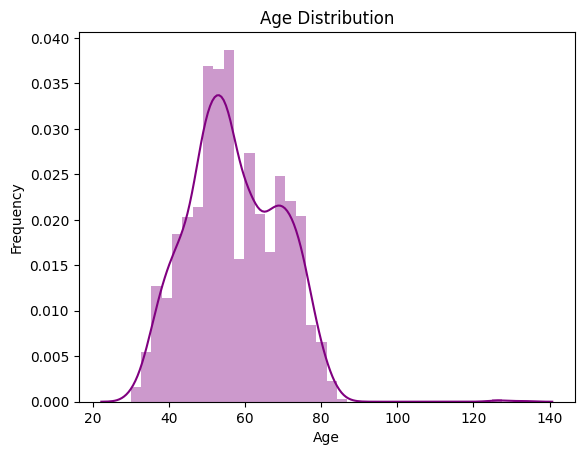

In [91]:
sns.distplot(age, color='purple')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [ ]:
print(age.skew())
print(age.kurtosis()) # just above the excess kurtosis of normal distribution!

0.34994385918267057
0.717464442459125


In [93]:
print(age.mean()) #mean is little shifted, should check for outleirs
print(age.median())

57.19419642857143
56.0


In [95]:
age.isna().sum()

np.int64(0)

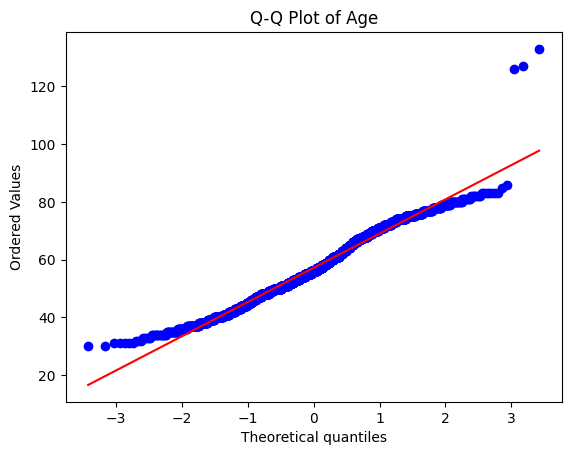

In [96]:
stats.probplot(age, dist='norm', plot=plt)
plt.title('Q-Q Plot of Age')
plt.show() # slightly right skewed but near normal.

In [97]:
q1 = np.percentile(age, 25)
q3 = np.percentile(age, 75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = age[(age < lower_bound) | (age > upper_bound)]
print(outliers.shape)

(3,)


In [98]:
outliers

192    126
239    133
339    127
Name: Age, dtype: int64

In [99]:
df = df[df["Age"] <= 100] # filtering.

In [100]:
df.columns

Index(['ID', 'Education', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age',
       'Marital_Status_Divorced', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Together',
       'Marital_Status_Widow'],
      dtype='object')

In [101]:
df.head()

,ID,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,5524,Graduation,58138.0,0,0,2012-09-04,58,635,88,546,...,0,3,11,1,69,0.0,0.0,1.0,0.0,0.0
1,2174,Graduation,46344.0,1,1,2014-03-08,38,11,1,6,...,0,3,11,0,72,0.0,0.0,1.0,0.0,0.0
2,4141,Graduation,71613.0,0,0,2013-08-21,26,426,49,127,...,0,3,11,0,61,0.0,0.0,0.0,1.0,0.0
3,6182,Graduation,26646.0,1,0,2014-02-10,26,11,4,20,...,0,3,11,0,42,0.0,0.0,0.0,1.0,0.0
4,5324,PhD,58293.0,1,0,2014-01-19,94,173,43,118,...,0,3,11,0,45,0.0,1.0,0.0,0.0,0.0


In [102]:
education = df['Education']
education.value_counts()

Education
Graduation    1127
PhD            485
Master         370
2n Cycle       201
Basic           54
Name: count, dtype: int64

In [103]:
education_encoded = ohe.fit_transform(df[['Education']])
education_encoded_df = pd.DataFrame(education_encoded, columns=ohe.get_feature_names_out(['Education']),  index=df.index)
df = pd.concat([df, education_encoded_df], axis=1)
df

,ID,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD
0,5524,Graduation,58138.0,0,0,2012-09-04,58,635,88,546,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2174,Graduation,46344.0,1,1,2014-03-08,38,11,1,6,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,4141,Graduation,71613.0,0,0,2013-08-21,26,426,49,127,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,6182,Graduation,26646.0,1,0,2014-02-10,26,11,4,20,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,5324,PhD,58293.0,1,0,2014-01-19,94,173,43,118,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,Graduation,61223.0,0,1,2013-06-13,46,709,43,182,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2236,4001,PhD,64014.0,2,1,2014-06-10,56,406,0,30,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2237,7270,Graduation,56981.0,0,0,2014-01-25,91,908,48,217,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2238,8235,Master,69245.0,0,1,2014-01-24,8,428,30,214,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [104]:
df.drop('Education', axis=1, inplace=True)
df.columns

Index(['ID', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact',
       'Z_Revenue', 'Response', 'Age', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Single',
       'Marital_Status_Together', 'Marital_Status_Widow', 'Education_2n Cycle',
       'Education_Basic', 'Education_Graduation', 'Education_Master',
       'Education_PhD'],
      dtype='object')

In [105]:
from sklearn.preprocessing import StandardScaler;

cols = ["ID",
    "Dt_Customer",
    "Z_CostContact",
    "Z_Revenue",
    "Response",
    "Complain",
    "AcceptedCmp1",
    'Education_2n Cycle',
       'Education_Basic', 'Education_Graduation', 'Education_Master',
       'Education_PhD',
 'Marital_Status_Divorced','Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow',
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5"]

X = df.drop(cols, axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X.columns

Index(['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Age'],
      dtype='object')

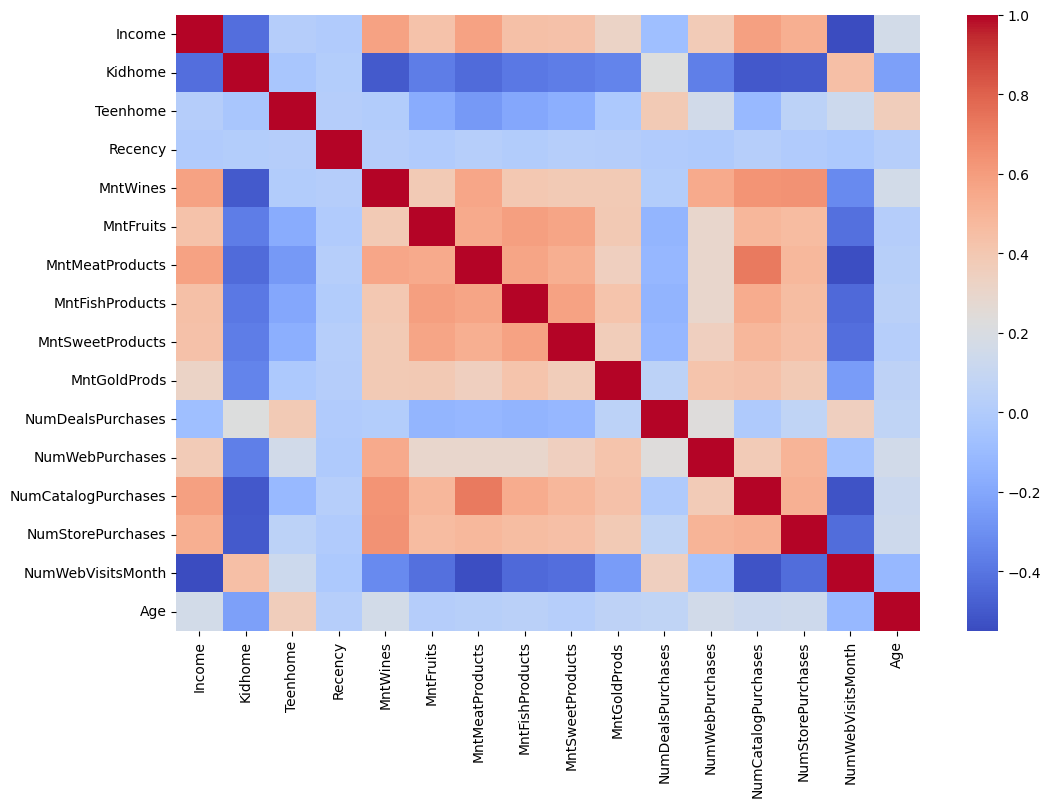

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.show()

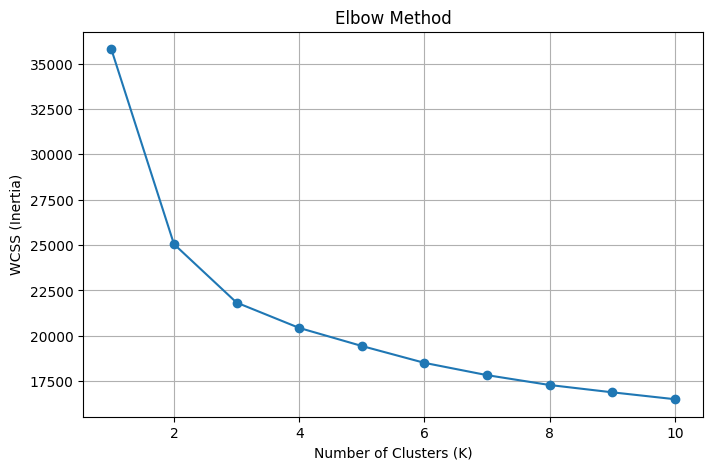

In [107]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1, 11):
    model = KMeans( n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

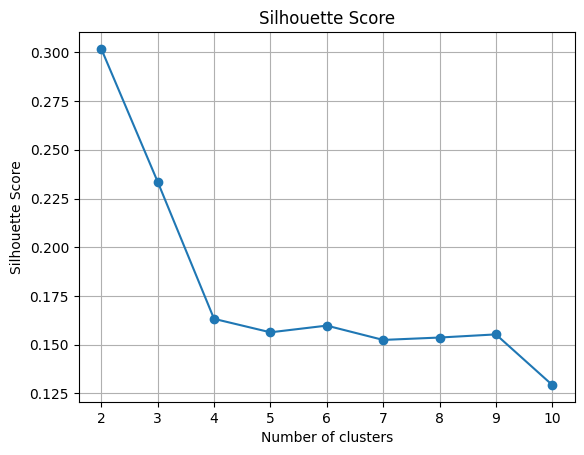

In [ ]:
from sklearn.metrics import silhouette_score

score = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    labels = model.fit_predict(X_scaled)
    score.append(silhouette_score(X_scaled, labels))

plt.plot(range(2, 11), score, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show() # highest at k = 2.

In [ ]:
kmeans = KMeans( # selecting k = 3 for better business insights!
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [110]:
df

,ID,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Cluster
0,5524,58138.0,0,0,2012-09-04,58,635,88,546,172,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
1,2174,46344.0,1,1,2014-03-08,38,11,1,6,2,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2
2,4141,71613.0,0,0,2013-08-21,26,426,49,127,111,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0
3,6182,26646.0,1,0,2014-02-10,26,11,4,20,10,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2
4,5324,58293.0,1,0,2014-01-19,94,173,43,118,46,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,61223.0,0,1,2013-06-13,46,709,43,182,42,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
2236,4001,64014.0,2,1,2014-06-10,56,406,0,30,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1
2237,7270,56981.0,0,0,2014-01-25,91,908,48,217,32,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
2238,8235,69245.0,0,1,2014-01-24,8,428,30,214,80,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1


In [111]:
df["Cluster"].value_counts()

Cluster
2    1016
1     627
0     594
Name: count, dtype: int64

In [112]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)
cluster_summary

,ID,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD
Cluster,,,,,,,,,,,,,,,,,,,,,
0,5662.345118,76354.539562,0.047138,0.170034,49.486532,587.974747,69.274411,450.392256,99.398990,71.196970,...,0.094276,0.360269,0.245791,0.257576,0.042088,0.094276,0.001684,0.560606,0.141414,0.202020
1,5485.293461,57780.507177,0.232855,0.945774,48.370016,462.719298,20.161085,132.044657,28.553429,21.116427,...,0.122807,0.408293,0.157895,0.267943,0.043062,0.055821,0.001595,0.472089,0.196172,0.274322
2,5613.920276,34694.622539,0.807087,0.432087,49.334646,40.015748,4.898622,22.704724,6.882874,4.942913,...,0.096457,0.387795,0.237205,0.253937,0.024606,0.108268,0.051181,0.490157,0.160433,0.189961


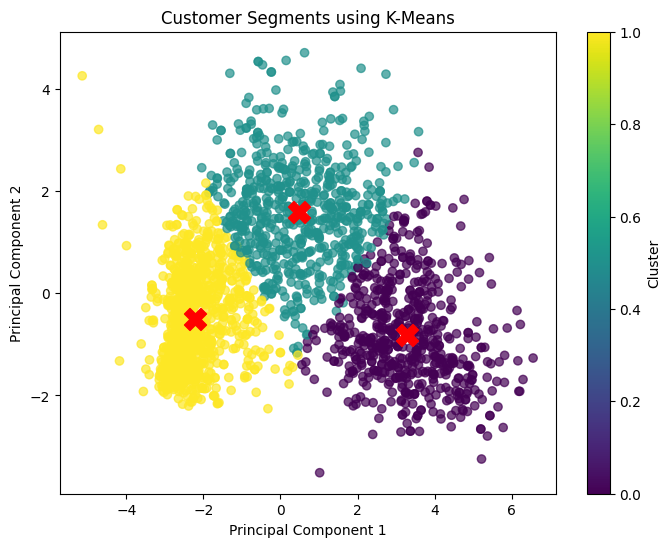

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

centroids = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c="red",
    s=250,
    marker="X",
    label="Centroids"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments using K-Means")
plt.colorbar(label="Cluster")
plt.show() # quite near clustered